In [2]:
import pandas as pd
df = pd.read_csv("farmer_scoring_sample_yogyank_round1_final.csv")

In [4]:
print(df.head())

  farmer_id  application_year    district  land_area_acres crop_type  \
0    F00001              2023     Cuttack            16.71   Soybean   
1    F00002              2022        Puri            11.72     Wheat   
2    F00003              2023        Puri            10.44   Soybean   
3    F00004              2023  Mayurbhanj             6.72    Cotton   
4    F00005              2023      Ganjam            11.28     Wheat   

  pm_kisan_status  historical_repayment_score irrigation_type land_ownership  \
0             Yes                       59.77       Irrigated          Owned   
1             Yes                       60.84         Rainfed          Owned   
2             Yes                       54.06         Rainfed          Owned   
3             Yes                       45.04       Irrigated          Owned   
4              No                       57.73       Irrigated          Owned   

   soil_type   sales_channel  annual_income_inr  liability_ratio_pct  \
0      Black  

In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   farmer_id                    5000 non-null   str    
 1   application_year             5000 non-null   int64  
 2   district                     5000 non-null   str    
 3   land_area_acres              5000 non-null   float64
 4   crop_type                    5000 non-null   str    
 5   pm_kisan_status              5000 non-null   str    
 6   historical_repayment_score   5000 non-null   float64
 7   irrigation_type              5000 non-null   str    
 8   land_ownership               5000 non-null   str    
 9   soil_type                    5000 non-null   str    
 10  sales_channel                5000 non-null   str    
 11  annual_income_inr            5000 non-null   float64
 12  liability_ratio_pct          5000 non-null   float64
 13  rainfall_deviation_pct       

In [6]:
print(df.shape)

(5000, 17)


In [7]:
print(df.columns.tolist())

['farmer_id', 'application_year', 'district', 'land_area_acres', 'crop_type', 'pm_kisan_status', 'historical_repayment_score', 'irrigation_type', 'land_ownership', 'soil_type', 'sales_channel', 'annual_income_inr', 'liability_ratio_pct', 'rainfall_deviation_pct', 'ndvi_score', 'defaulted_in_next_12_months', 'target_entitlement_score']


In [5]:
df.isnull().sum()

farmer_id                      0
application_year               0
district                       0
land_area_acres                0
crop_type                      0
pm_kisan_status                0
historical_repayment_score     0
irrigation_type                0
land_ownership                 0
soil_type                      0
sales_channel                  0
annual_income_inr              0
liability_ratio_pct            0
rainfall_deviation_pct         0
ndvi_score                     0
defaulted_in_next_12_months    0
target_entitlement_score       0
dtype: int64

In [7]:
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


farmer_id
farmer_id
F00001    1
F00002    1
F00003    1
F00004    1
F00005    1
         ..
F04996    1
F04997    1
F04998    1
F04999    1
F05000    1
Name: count, Length: 5000, dtype: int64

district
district
Mayurbhanj    860
Balasore      847
Cuttack       845
Puri          837
Ganjam        807
Bhadrak       804
Name: count, dtype: int64

crop_type
crop_type
Soybean      762
Cotton       741
Rice         728
Wheat        702
Sugarcane    702
Maize        694
Millets      671
Name: count, dtype: int64

pm_kisan_status
pm_kisan_status
Yes    3338
No     1662
Name: count, dtype: int64

irrigation_type
irrigation_type
Irrigated    2747
Rainfed      2253
Name: count, dtype: int64

land_ownership
land_ownership
Owned     3664
Tenant    1336
Name: count, dtype: int64

soil_type
soil_type
Red           884
Alluvial      849
Sandy Loam    832
Laterite      821
Black         818
Clay Loam     796
Name: count, dtype: int64

sales_channel
sales_channel
Contract Buyer    1287
Local Trader    

C:\Users\ssssa\AppData\Local\Temp\ipykernel_18720\1793038935.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns


In [8]:
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].nunique())


farmer_id
5000

district
6

crop_type
7

pm_kisan_status
2

irrigation_type
2

land_ownership
2

soil_type
6

sales_channel
4


In [9]:
df.describe()

,application_year,land_area_acres,historical_repayment_score,annual_income_inr,liability_ratio_pct,rainfall_deviation_pct,ndvi_score,defaulted_in_next_12_months,target_entitlement_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2022.901000,9.155648,65.820980,364130.589572,21.013140,0.276454,0.551123,0.096200,778.541736
std,0.804319,5.131744,17.674808,163721.231395,12.316053,16.990974,0.119917,0.294895,153.218914
min,2022.000000,0.410000,0.000000,80412.070000,0.020000,-54.680000,0.150000,0.000000,170.960000
25%,2022.000000,4.610000,53.670000,222658.992500,10.390000,-11.192500,0.471000,0.000000,752.292500
50%,2023.000000,9.180000,65.855000,366459.020000,20.850000,0.120000,0.552000,0.000000,815.330000
75%,2024.000000,13.610000,78.470000,504990.985000,31.927500,11.522500,0.632000,0.000000,868.555000
max,2024.000000,18.000000,100.000000,649743.540000,42.000000,65.640000,0.880000,1.000000,980.000000


In [10]:
df["application_year"].value_counts().sort_index()

application_year
2022    1889
2023    1717
2024    1394
Name: count, dtype: int64

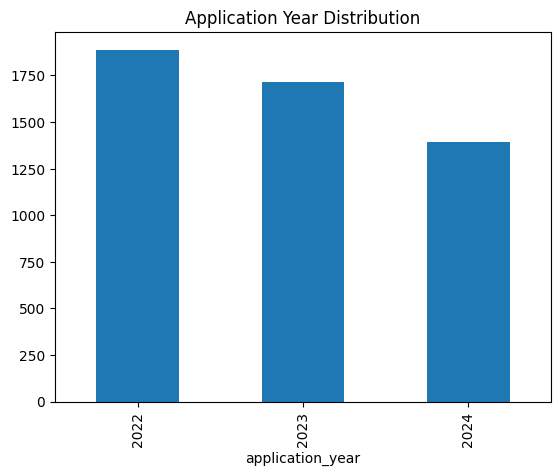

In [12]:
import matplotlib.pyplot as plt

df["application_year"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Application Year Distribution")
plt.show()

In [11]:
TARGET = "target_entitlement_score"

df[TARGET].describe()

count    5000.000000
mean      778.541736
std       153.218914
min       170.960000
25%       752.292500
50%       815.330000
75%       868.555000
max       980.000000
Name: target_entitlement_score, dtype: float64

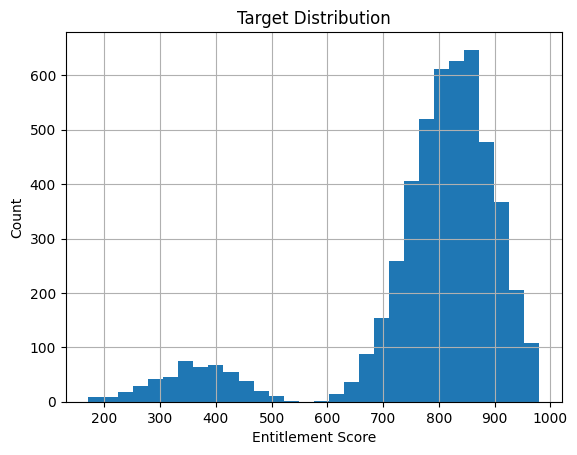

In [13]:
df[TARGET].hist(bins=30)

plt.title("Target Distribution")
plt.xlabel("Entitlement Score")
plt.ylabel("Count")

plt.show()

In [14]:
df.groupby("application_year")[TARGET].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
application_year,,,,,
2022,1889,765.928989,805.230,177.31,980.0
2023,1717,783.689220,818.980,170.96,980.0
2024,1394,789.292991,825.945,171.74,980.0


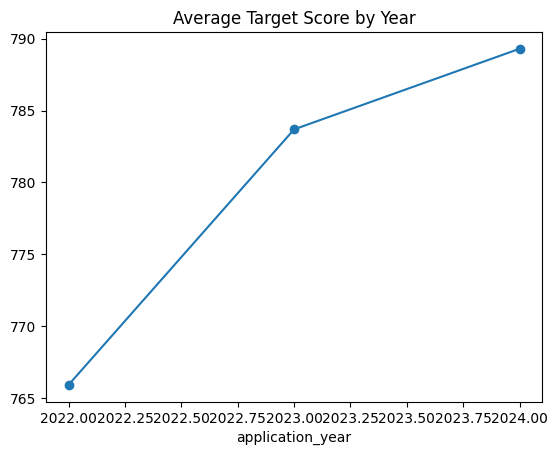

In [15]:
df.groupby("application_year")[TARGET].mean().plot(
    marker="o"
)

plt.title("Average Target Score by Year")
plt.show()

In [17]:
import numpy as np
numeric_cols = df.select_dtypes(include=np.number)

corr = numeric_cols.corr()[TARGET].sort_values(
    ascending=False
)

corr

target_entitlement_score       1.000000
historical_repayment_score     0.433690
land_area_acres                0.238363
application_year               0.063001
liability_ratio_pct            0.040414
annual_income_inr              0.013288
ndvi_score                    -0.017809
rainfall_deviation_pct        -0.020718
defaulted_in_next_12_months   -0.885544
Name: target_entitlement_score, dtype: float64

In [18]:
df.groupby(
    "defaulted_in_next_12_months"
)[TARGET].describe()

,count,mean,std,min,25%,50%,75%,max
defaulted_in_next_12_months,,,,,,,,
0,4519.0,822.803682,71.108966,599.46,774.49,824.49,873.565,980.00
1,481.0,362.700291,71.904792,170.96,313.83,364.79,414.880,537.16


In [19]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print()

print("Missing Values")
print(df.isnull().sum())

print()
print("Years")
print(df["application_year"].value_counts().sort_index())

print()
print("Target Summary")
print(df["target_entitlement_score"].describe())

Rows: 5000
Columns: 17

Missing Values
farmer_id                      0
application_year               0
district                       0
land_area_acres                0
crop_type                      0
pm_kisan_status                0
historical_repayment_score     0
irrigation_type                0
land_ownership                 0
soil_type                      0
sales_channel                  0
annual_income_inr              0
liability_ratio_pct            0
rainfall_deviation_pct         0
ndvi_score                     0
defaulted_in_next_12_months    0
target_entitlement_score       0
dtype: int64

Years
application_year
2022    1889
2023    1717
2024    1394
Name: count, dtype: int64

Target Summary
count    5000.000000
mean      778.541736
std       153.218914
min       170.960000
25%       752.292500
50%       815.330000
75%       868.555000
max       980.000000
Name: target_entitlement_score, dtype: float64
